In [ ]:
from google.colab import drive
drive.mount(r"/content/drive")

Mounted at /content/drive


# Import Modules

In [ ]:
#pip install opencv-python

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import PIL
import tensorflow as tf
import cv2 as cv2

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import pandas as pd

import pathlib

In [ ]:
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
! nvidia-smi

Tue Jul  5 16:27:07 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   73C    P0    31W /  70W |    264MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
train_df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/comp5152/train_df.csv')  
valid_df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/comp5152/valid_df.csv') 
test_df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/comp5152/test_df.csv') 

In [ ]:
train_df
#valid_df
#test_df

,Unnamed: 0,filepaths,labels,data_set
0,0,/content/drive/MyDrive/Colab Notebooks/comp515...,air hockey,train
1,1,/content/drive/MyDrive/Colab Notebooks/comp515...,air hockey,train
2,2,/content/drive/MyDrive/Colab Notebooks/comp515...,air hockey,train
3,3,/content/drive/MyDrive/Colab Notebooks/comp515...,air hockey,train
4,4,/content/drive/MyDrive/Colab Notebooks/comp515...,air hockey,train
...,...,...,...,...
16995,16995,/content/drive/MyDrive/Colab Notebooks/comp515...,wingsuit flying,NaN
16996,16996,/content/drive/MyDrive/Colab Notebooks/comp515...,wingsuit flying,NaN
16997,16997,/content/drive/MyDrive/Colab Notebooks/comp515...,wingsuit flying,NaN
16998,16998,/content/drive/MyDrive/Colab Notebooks/comp515...,wingsuit flying,NaN


# load data

In [ ]:
batch_size = 32
img_size=(224,224) # size of augmented images


trgen=ImageDataGenerator(horizontal_flip=True,rotation_range=20, width_shift_range=.2,
                                  height_shift_range=.2, zoom_range=.2 )
t_and_v_gen=ImageDataGenerator()
train_gen=trgen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size)
valid_gen=t_and_v_gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=batch_size)
# for the test_gen we want to calculate the batch size and test steps such that batch_size X test_steps= number of samples in test set
# this insures that we go through all the sample in the test set exactly once.
length=len(test_df)
test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80],reverse=True)[0]  
test_steps=int(length/test_batch_size)
test_gen=t_and_v_gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=test_batch_size)
# from the generator we can get information we will need later
classes=list(train_gen.class_indices.keys())
class_indices=list(train_gen.class_indices.values())
class_count=len(classes)
labels=test_gen.labels
print ( 'test batch size: ' ,test_batch_size, '  test steps: ', test_steps, ' number of classes : ', class_count)



/usr/local/lib/python3.7/dist-packages/keras_preprocessing/image/dataframe_iterator.py:282: UserWarning: Found 3766 invalid image filename(s) in x_col="filepaths". These filename(s) will be ignored.
  .format(n_invalid, x_col)


Found 13234 validated image filenames belonging to 100 classes.
Found 500 validated image filenames belonging to 100 classes.
Found 499 validated image filenames belonging to 100 classes.
test batch size:  50   test steps:  10  number of classes :  100


/usr/local/lib/python3.7/dist-packages/keras_preprocessing/image/dataframe_iterator.py:282: UserWarning: Found 1 invalid image filename(s) in x_col="filepaths". These filename(s) will be ignored.
  .format(n_invalid, x_col)


# load model

In [ ]:
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
import time

img_shape=(224,224,3)

model_name='EfficientNetB3'
base_model=tf.keras.applications.efficientnet.EfficientNetB3(include_top=False, weights="imagenet",input_shape=img_shape, pooling='max') 
base_model.trainable=True
x=base_model.output
x=BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
x = Dense(256, kernel_regularizer = regularizers.l2(l = 0.016),activity_regularizer=regularizers.l1(0.006),
                bias_regularizer=regularizers.l1(0.006) ,activation='relu')(x)
x=Dropout(rate=.4, seed=123)(x)       
output=Dense(class_count, activation='softmax')(x)
model=Model(inputs=base_model.input, outputs=output)
lr=.001 # start with this learning rate
model.compile(Adamax(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy']) 

class ASK(keras.callbacks.Callback):
    def __init__ (self, model, epochs,  ask_epoch): # initialization of the callback
        super(ASK, self).__init__()
        self.model=model               
        self.ask_epoch=ask_epoch
        self.epochs=epochs
        self.ask=True # if True query the user on a specified epoch
        
    def on_train_begin(self, logs=None): # this runs on the beginning of training
        if self.ask_epoch == 0: 
            print('you set ask_epoch = 0, ask_epoch will be set to 1', flush=True)
            self.ask_epoch=1
        if self.ask_epoch >= self.epochs: # you are running for epochs but ask_epoch>epochs
            print('ask_epoch >= epochs, will train for ', epochs, ' epochs', flush=True)
            self.ask=False # do not query the user
        if self.epochs == 1:
            self.ask=False # running only for 1 epoch so do not query user
        else:
            print('Training will proceed until epoch', ask_epoch,' then you will be asked to') 
            print(' enter H to halt training or enter an integer for how many more epochs to run then be asked again')  
        self.start_time= time.time() # set the time at which training started
        
    def on_train_end(self, logs=None):   # runs at the end of training     
        tr_duration=time.time() - self.start_time   # determine how long the training cycle lasted         
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print (msg, flush=True) # print out training duration time
        
    def on_epoch_end(self, epoch, logs=None):  # method runs on the end of each epoch
        if self.ask: # are the conditions right to query the user?
            if epoch + 1 ==self.ask_epoch: # is this epoch the one for quering the user?
                print('\n Enter H to end training or  an integer for the number of additional epochs to run then ask again')
                ans=input()
                
                if ans == 'H' or ans =='h' or ans == '0': # quit training for these conditions
                    print ('you entered ', ans, ' Training halted on epoch ', epoch+1, ' due to user input\n', flush=True)
                    self.model.stop_training = True # halt training
                else: # user wants to continue training
                    self.ask_epoch += int(ans)
                    if self.ask_epoch > self.epochs:
                        print('\nYou specified maximum epochs of as ', self.epochs, ' cannot train for ', self.ask_epoch, flush =True)
                    else:
                        print ('you entered ', ans, ' Training will continue to epoch ', self.ask_epoch, flush=True)




43950080/43941136 [==============================] - 0s 0us/step


In [ ]:
epochs=5
ask_epoch=1
ask=ASK(model, epochs,  ask_epoch)
rlronp=tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2,verbose=1)
estop=tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, verbose=1,restore_best_weights=True)
callbacks=[rlronp, estop, ask]

# Training

In [ ]:
history=model.fit(x=train_gen,  epochs=epochs, verbose=1, callbacks=callbacks,  validation_data=valid_gen,
               validation_steps=None,  shuffle=False,  initial_epoch=0)

Training will proceed until epoch 1  then you will be asked to
 enter H to halt training or enter an integer for how many more epochs to run then be asked again
Epoch 1/5
414/414 [==============================] - ETA: 0s - loss: 3.6547 - accuracy: 0.8257
 Enter H to end training or  an integer for the number of additional epochs to run then ask again
1
you entered  1  Training will continue to epoch  2
414/414 [==============================] - 890s 2s/step - loss: 3.6547 - accuracy: 0.8257 - val_loss: 2.1709 - val_accuracy: 0.9400 - lr: 0.0010
Epoch 2/5
414/414 [==============================] - ETA: 0s - loss: 1.9781 - accuracy: 0.8935
 Enter H to end training or  an integer for the number of additional epochs to run then ask again
1
you entered  1  Training will continue to epoch  3
414/414 [==============================] - 313s 755ms/step - loss: 1.9781 - accuracy: 0.8935 - val_loss: 1.2844 - val_accuracy: 0.9620 - lr: 0.0010
Epoch 3/5
414/414 [==============================] - E

# Save model

In [ ]:
model.save(r'/content/drive/MyDrive/Colab Notebooks/comp5152/model')

INFO:tensorflow:Assets written to: /content/drive/MyDrive/Colab Notebooks/comp5152/model/assets


# Loss and Accuracy

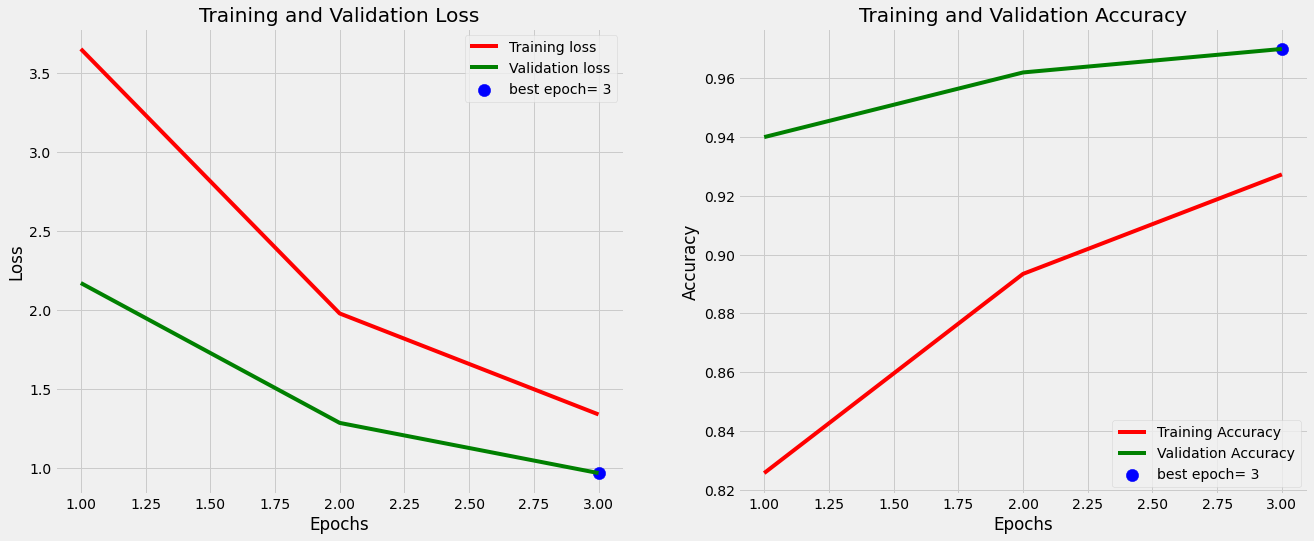

In [ ]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)   
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout    
    plt.show()
    
tr_plot(history,0)

# Prediction

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def predictor(test_gen, test_steps):
    y_pred= []
    y_true=test_gen.labels
    classes=list(train_gen.class_indices.keys())
    class_count=len(classes)
    errors=0
    preds=model.predict(test_gen, steps=test_steps, verbose=1) # predict on the test set
    tests=len(preds)
    for i, p in enumerate(preds):
            pred_index=np.argmax(p)         
            true_index=test_gen.labels[i]  # labels are integer values
            if pred_index != true_index: # a misclassification has occurred                                           
                errors=errors + 1
            y_pred.append(pred_index)
    acc=( 1-errors/tests) * 100
    print(f'there were {errors} in {tests} tests for an accuracy of {acc:6.2f}')
    ypred=np.array(y_pred)
    ytrue=np.array(y_true)
    if class_count <=30:
        cm = confusion_matrix(ytrue, ypred )
        # plot the confusion matrix
        plt.figure(figsize=(16, 10))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)       
        plt.xticks(np.arange(class_count)+.5, classes, rotation=90)
        plt.yticks(np.arange(class_count)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes, digits= 4) # create classification report
    print("Classification Report:\n----------------------\n", clr)
    
predictor(test_gen, test_steps)

10/10 [==============================] - 26s 3s/step
there were 16 in 499 tests for an accuracy of  96.79
Classification Report:
----------------------
                        precision    recall  f1-score   support

           air hockey     1.0000    1.0000    1.0000         4
      ampute football     1.0000    1.0000    1.0000         5
              archery     1.0000    1.0000    1.0000         5
        arm wrestling     1.0000    1.0000    1.0000         5
         axe throwing     1.0000    1.0000    1.0000         5
         balance beam     1.0000    1.0000    1.0000         5
        barell racing     1.0000    1.0000    1.0000         5
             baseball     1.0000    0.6000    0.7500         5
           basketball     0.8333    1.0000    0.9091         5
       baton twirling     1.0000    1.0000    1.0000         5
            bike polo     1.0000    1.0000    1.0000         5
            billiards     1.0000    1.0000    1.0000         5
                  bmx     1

In [ ]:
test_valid_img_path = pathlib.Path("/content/drive/MyDrive/Colab Notebooks/comp5152/test/cricket/1.jpg")
img_size=(224,224)
img = tf.keras.utils.load_img(
    test_valid_img_path, target_size=(224,224)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

preds = model.predict(img_array)
pred_index = np.argmax(preds)
list(train_gen.class_indices.keys())[pred_index]



'cricket'